# 05. Análisis de resultados

Este informe ejecuta la fase de evaluación cuantitativa del pipeline experimental trabajando directamente sobre la tabla maestra sintetizada (`results/experiments_master.csv`+`results\svm_gpu_results_colab.csv`).

### Objetivo prioritario:
Dado que la **métrica clave definida para este problema es el $F_1$-score**, la evaluación prioriza la maximización de la media armónica entre la Precisión ($\text{Precision}$) y la Sensibilidad ($\text{Recall}$). Esto es crítico en escenarios donde existe un desbalance de clases relevante y se busca un equilibrio óptimo entre minimizar los falsos negativos y controlar la tasa de falsos positivos, garantizando una detección robusta y confiable.

---

**Contenido:** 
* Tabla de métricas resumidas ($\text{media} \pm \text{desviación estándar}$ en el *outer loop*).
* Métricas complementarias (ROC-AUC, PR-AUC; $F_1$ sigue siendo la principal) y desviaciones con `ddof=1`.
* Comparación estadística jerárquica (Friedman, Nemenyi, CD diagram, DeLong con corrección Holm, Cliff's Delta), con carácter descriptivo por las limitaciones indicadas en esa sección, más una comparación por factor (técnica, método, modelo) que sí tiene potencia.
* Matriz de confusión y curva ROC de la combinación con mayor $F_1$-score medio.
* Diagnóstico de calibración probabilística (Brier score, ECE y *reliability diagram*) + recalibración por regresión isotónica.
* Análisis de complejidad computacional y *trade-off* de recursos (estándar vs. optimizado).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from src import config
from src.data_loader import load_processed_dataset, split_features_target
from src.synthetic_data import generate_synthetic_dataset
from src.preprocessing import remove_duplicate_rows
from src.models import MODEL_REGISTRY
from src.experiment_runner import load_master_table
from src.evaluation import (
    format_metrics_table,
    regenerate_outof_fold_predictions,
    evaluate_calibration,
    is_calibration_poor,
    assess_and_recalibrate,
)
from src.complexity_analysis import compare_standard_vs_optimized, TRAIN_INFERENCE_COMPLEXITY
from src import stats_comparison as sc

np.random.seed(config.RANDOM_STATE)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Cargar datos y tabla maestra

Se carga el dataset procesado garantizando la reproducibilidad del orden de los datos y se consolida la tabla maestra combinada.

**Nota de comparabilidad de las filas de SVM (Colab).** Las 16 filas de `svm` provienen de `07_svm_gpu_colab.ipynb` y no son estrictamente comparables con las otras 96:
- Se usó `cuml.svm.SVC` en una GPU A100-40GB, no `sklearn.svm.SVC` (libsvm). El solver y la calibración de probabilidades (Platt) no son idénticos. Además, `cache_size` fue 2048 frente a 500 en local.
- Versiones en Colab: scikit-learn 1.6.1, numpy 2.0.2 y pandas 2.2.2. Local: 1.9.1, 2.5.3 y 3.0.6.
- No se guardan los índices de los folds. Con el mismo `random_state=42` y el mismo dataset (misma forma y tamaño de archivo) los folds deberían coincidir, pero no se puede verificar fila a fila.
- Los tiempos de SVM (GPU) no son comparables con los de los demás modelos (CPU).
- Las filas `knn|class_weight` y `naive_bayes|class_weight` usan wrappers propios (`models.py`), no el soporte nativo de scikit-learn.
- Las desviaciones estándar se calculan con `np.std` (ddof=0); con 3 folds subestiman la dispersión.

In [2]:
import pandas as pd

try:
    df = load_processed_dataset()
except FileNotFoundError:
    df = generate_synthetic_dataset()
df, _ = remove_duplicate_rows(df)
X, y = split_features_target(df)

# 1. Cargar la tabla maestra principal
table_master = load_master_table(config.EXPERIMENTS_MASTER_PATH)

# 2. Cargar la tabla adicional de SVM desde Colab
colab_csv_path = config.PROJECT_ROOT / "results" / "svm_gpu_results_colab.csv"

if colab_csv_path.exists():
    table_colab = load_master_table(colab_csv_path)
    # Concatenar ambas tablas y eliminar duplicados basados en combinación única
    table = pd.concat([table_master, table_colab], ignore_index=True)
    table = table.drop_duplicates(subset=["model", "technique", "method"], keep="last")
else:
    table = table_master

if table.empty:
    raise RuntimeError("La tabla maestra está vacía. Correr primero 04_run_experiments.ipynb o verificar los CSVs.")

print(f"{len(table)} combinaciones en la tabla maestra combinada.")

112 combinaciones en la tabla maestra combinada.


## Tabla de métricas (media ± desviación estándar, outer loop)

In [3]:
metric_for_ranking = config.DEFAULT_SCORING
table_sorted = table.sort_values(f"{metric_for_ranking}_mean", ascending=False)
format_metrics_table(table_sorted)

,model,technique,method,accuracy,precision,recall,f1,roc_auc
79,random_forest,class_weight,genetic_deap,0.7776 ± 0.0053,0.498 ± 0.0098,0.6042 ± 0.0092,0.546 ± 0.0088,0.7813 ± 0.0056
77,random_forest,class_weight,random_search,0.7759 ± 0.007,0.4951 ± 0.0129,0.6071 ± 0.006,0.5453 ± 0.0088,0.782 ± 0.0045
62,xgboost,class_weight,bayesian_optuna,0.7726 ± 0.0094,0.4896 ± 0.0161,0.6154 ± 0.0089,0.5451 ± 0.0099,0.7817 ± 0.0041
76,random_forest,class_weight,grid_search,0.7743 ± 0.004,0.492 ± 0.0072,0.6103 ± 0.0112,0.5448 ± 0.0074,0.7833 ± 0.0039
78,random_forest,class_weight,bayesian_optuna,0.7785 ± 0.0068,0.4998 ± 0.0126,0.598 ± 0.0035,0.5444 ± 0.0079,0.7804 ± 0.0055
...,...,...,...,...,...,...,...,...
82,knn,none,bayesian_optuna,0.8023 ± 0.0028,0.5924 ± 0.0134,0.3418 ± 0.0019,0.4334 ± 0.0038,0.7318 ± 0.0146
19,logistic_regression,none,genetic_deap,0.8071 ± 0.0017,0.6599 ± 0.0114,0.2647 ± 0.0024,0.3778 ± 0.0037,0.75 ± 0.0096
18,logistic_regression,none,bayesian_optuna,0.8071 ± 0.0017,0.6597 ± 0.0113,0.2647 ± 0.0024,0.3778 ± 0.0037,0.75 ± 0.0096
16,logistic_regression,none,grid_search,0.8071 ± 0.0017,0.6597 ± 0.0113,0.2647 ± 0.0024,0.3778 ± 0.0037,0.75 ± 0.0096


Cambiando el parámetro de ranking a **`f1`**, la tabla posiciona en los primeros lugares los modelos con mejor balance armónico entre precisión y recall:

**Hallazgos bajo F1 Score (descriptivos):**
- El modelo **`random_forest`** combinado con **`class_weight`** y optimizado mediante **`genetic_deap`** tiene el **F1 Score medio más alto del experimento: $0.5460 \pm 0.0088$**.
- Le siguen `random_forest` con `class_weight` ($0.5453 \pm 0.0088$ mediante `random_search`) y **`xgboost`** con `class_weight` ($0.5451 \pm 0.0099$ mediante `bayesian_optuna`). Las diferencias con la primera (0.0006 y 0.0008) son mucho menores que la desviación estándar entre folds: 15 de las 112 combinaciones, incluida la primera, quedan a menos de una desviación estándar de ella (0.0088) y 6 a menos de 0.0016. El orden entre ellas es descriptivo y no indica una mejor configuración (ver comparación estadística más abajo).
- La aplicación de técnicas de balanceo como `class_weight` aumenta el F1 Score frente a las configuraciones sin balanceo (`none`), que presentan un F1 menor por su baja sensibilidad: el recall medio por técnica pasa de 0.37 (`none`) a 0.61 (`class_weight`).
- Esa mejora viene en gran parte del balanceo y del umbral de decisión (0.5), no de una mejor capacidad para ordenar clientes. En regresión logística, el F1 pasa de 0.378 (`none`) a 0.515 (SMOTE o `class_weight`) y el recall de 0.26 a 0.62, mientras que el ROC-AUC casi no cambia (0.750 sin balanceo, 0.747 a 0.750 con SMOTE o `class_weight`). Entre todas las combinaciones, el ROC-AUC medio por técnica queda entre 0.751 y 0.762.

## Métricas complementarias (independientes del umbral)

El $F_1$ sigue siendo la métrica principal: es la que optimizan los cuatro métodos de búsqueda y la que ordena todo el análisis. Se agregan, solo para reportar, el ROC-AUC y el PR-AUC (*average precision*), que miden qué tan bien ordena el modelo a los clientes sin depender del umbral de 0.5, y se recalcula la desviación estándar entre folds con `ddof=1` (la columna `*_std` de la tabla maestra usa `ddof=0`).

El PR-AUC no estaba en la corrida original. Se calcula a posteriori con `src/posthoc_metrics.py`, que reajusta cada pipeline con los hiperparámetros ya elegidos en cada fold externo (un `fit` por fold, sin nueva búsqueda) y comprueba que el $F_1$ por fold coincide con el de la tabla maestra. **No incluye SVM**: sus filas vienen de cuML en GPU y reajustarlas con `sklearn.svm.SVC` daría otro modelo.

In [4]:
from src.posthoc_metrics import POSTHOC_METRICS_PATH
from src.stats_comparison import per_fold_std

posthoc = pd.read_csv(POSTHOC_METRICS_PATH) if POSTHOC_METRICS_PATH.exists() else pd.DataFrame()
key = ["model", "technique", "method"]
table_ext = table.copy()
table_ext["f1_std_ddof1"] = per_fold_std(table_ext, "f1")
if not posthoc.empty:
    table_ext = table_ext.merge(
        posthoc[key + ["f1_check_max_abs_diff", "pr_auc_posthoc_mean", "pr_auc_posthoc_std"]], on=key, how="left"
    )
    print(f"PR-AUC calculado para {posthoc.shape[0]} combinaciones; "
          f"diferencia máxima en F1 por fold frente a la tabla maestra: {posthoc['f1_check_max_abs_diff'].max():.2e}")
else:
    print("Falta results/experiments_posthoc_metrics.csv: correr `python -m src.posthoc_metrics`.")

cols = ["model", "technique", "method", "f1_mean", "f1_std_ddof1", "precision_mean", "recall_mean", "roc_auc_mean"]
if "pr_auc_posthoc_mean" in table_ext:
    cols += ["pr_auc_posthoc_mean"]
display(table_ext.sort_values("f1_mean", ascending=False)[cols].head(15).round(4))

print("Promedio por técnica de balanceo (las 96 combinaciones locales; SVM no tiene PR-AUC):")
agg = ["f1_mean", "precision_mean", "recall_mean", "roc_auc_mean"] + (["pr_auc_posthoc_mean"] if "pr_auc_posthoc_mean" in table_ext else [])
sub_local = table_ext[table_ext["model"] != "svm"]
display(sub_local.groupby("technique")[agg].mean().sort_values("f1_mean", ascending=False).round(4))

PR-AUC calculado para 96 combinaciones; diferencia máxima en F1 por fold frente a la tabla maestra: 0.00e+00


,model,technique,method,f1_mean,f1_std_ddof1,precision_mean,recall_mean,roc_auc_mean,pr_auc_posthoc_mean
79,random_forest,class_weight,genetic_deap,0.5460,0.0108,0.4980,0.6042,0.7813,0.5580
77,random_forest,class_weight,random_search,0.5453,0.0108,0.4951,0.6071,0.7820,0.5573
62,xgboost,class_weight,bayesian_optuna,0.5451,0.0122,0.4896,0.6154,0.7817,0.5545
76,random_forest,class_weight,grid_search,0.5448,0.0091,0.4920,0.6103,0.7833,0.5579
78,random_forest,class_weight,bayesian_optuna,0.5444,0.0097,0.4998,0.5980,0.7804,0.5567
60,xgboost,class_weight,grid_search,0.5444,0.0064,0.4972,0.6042,0.7800,0.5500
63,xgboost,class_weight,genetic_deap,0.5440,0.0127,0.4946,0.6048,0.7807,0.5576
61,xgboost,class_weight,random_search,0.5438,0.0114,0.4964,0.6017,0.7802,0.5517
111,svm,class_weight,genetic_deap,0.5385,0.0063,0.4753,0.6214,0.7635,NaN
107,svm,class_weight,bayesian_optuna,0.5384,0.0072,0.4745,0.6228,0.7639,NaN


Promedio por técnica de balanceo (las 96 combinaciones locales; SVM no tiene PR-AUC):


,f1_mean,precision_mean,recall_mean,roc_auc_mean,pr_auc_posthoc_mean
technique,,,,,
class_weight,0.5234,0.4603,0.6098,0.7614,0.5172
smote,0.5154,0.4914,0.5624,0.7540,0.5087
adasyn,0.5103,0.4809,0.5735,0.7493,0.5024
none,0.4557,0.6179,0.3768,0.7576,0.5135


**Lectura.** El $F_1$ lo lideran Random Forest y XGBoost con `class_weight` (0.544–0.546; desviación entre folds con `ddof=1` de 0.006 a 0.013). Sobre las 96 combinaciones locales, el balanceo cambia el punto de operación más que la capacidad de ordenar: sin balanceo el ROC-AUC medio (0.758) es mayor que con SMOTE (0.754) o ADASYN (0.749), y su PR-AUC (0.514) es mayor que con SMOTE (0.509) o ADASYN (0.502); solo `class_weight` mejora algo en ambos (0.761 y 0.517). Lo que sí cambia es el equilibrio entre recall y precisión al umbral de 0.5: el recall pasa de 0.377 (`none`) a 0.610 (`class_weight`) y la precisión baja de 0.618 a 0.460. Por eso la ganancia de $F_1$ al balancear (0.456 → 0.523) viene en gran parte del umbral y no de un modelo que discrimine mejor, lo que es coherente con que el $F_1$ siga siendo la métrica principal siempre que se lea así. Las diferencias de PR-AUC entre las ocho primeras combinaciones (0.550–0.558) son del orden de su variabilidad entre folds.

## Cobertura de la grilla: 112 combinaciones teóricas

Se documenta la matriz completa de 112 combinaciones teóricas (7 clasificadores $\times$ 4 técnicas de balanceo $\times$ 4 métodos de búsqueda) para fines de auditoría y cobertura experimental.

In [5]:
import pandas as pd
from src.balancing import BALANCING_TECHNIQUES, is_compatible
from src.optimization import OPTIMIZATION_METHODS

filas_teoricas = [
    (model_name, technique, method, is_compatible(spec, technique))
    for model_name, spec in MODEL_REGISTRY.items()
    for technique in BALANCING_TECHNIQUES
    for method in OPTIMIZATION_METHODS
]
reporte_112 = pd.DataFrame(filas_teoricas, columns=["model", "technique", "method", "compatible"])
reporte_112 = reporte_112.merge(
    table[["model", "technique", "method", f"{metric_for_ranking}_mean"]],
    on=["model", "technique", "method"], how="left",
)
reporte_112["estado"] = np.where(
    ~reporte_112["compatible"],
    "No aplica (sklearn no admite class_weight para este modelo)",
    np.where(reporte_112[f"{metric_for_ranking}_mean"].notna(), "Corrida", "Pendiente"),
)

print(f"Total de combinaciones teóricas: {len(reporte_112)}")
print(reporte_112["estado"].value_counts().to_string())
reporte_112.drop(columns="compatible").sort_values(["estado", "model", "technique", "method"])

Total de combinaciones teóricas: 112
estado
Corrida    112


,model,technique,method,f1_mean,estado
58,decision_tree,adasyn,bayesian_optuna,0.517838,Corrida
59,decision_tree,adasyn,genetic_deap,0.517838,Corrida
56,decision_tree,adasyn,grid_search,0.510033,Corrida
57,decision_tree,adasyn,random_search,0.517838,Corrida
62,decision_tree,class_weight,bayesian_optuna,0.516955,Corrida
...,...,...,...,...,...
81,xgboost,none,random_search,0.478821,Corrida
86,xgboost,smote,bayesian_optuna,0.519437,Corrida
87,xgboost,smote,genetic_deap,0.527377,Corrida
84,xgboost,smote,grid_search,0.534431,Corrida


## Comparación estadística jerárquica

Se aplica sobre las 112 combinaciones, con los 3 folds externos como bloques y el $F1\,Score$ como métrica. Los resultados deben leerse como evidencia **descriptiva**, no inferencial (ver limitación común al final):
1. **Prueba ómnibus de Friedman:** contrasta si todas las combinaciones son equivalentes en F1. Con $\chi^2 \approx 323$ ($p \approx 10^{-22}$) solo indica que no todas son iguales; no dice cuáles difieren.
2. **Nemenyi y diagrama de diferencia crítica (CD):** con 112 combinaciones y 3 folds la diferencia crítica es 115.4, mayor que la máxima diferencia observada entre rangos medios (107.7). Ningún par (0 de 6,216) es significativo, de modo que el diagrama no separa grupos y el ranking de rangos es descriptivo.
3. **DeLong (top 3 por F1):** compara el AUC (no el F1) de las tres combinaciones con mejor rango en F1. Se calcula sobre predicciones *out-of-fold* agrupadas, que provienen de tres modelos distintos (uno por fold), por lo que el AUC agrupado no coincide con `roc_auc_mean` (por ejemplo, 0.7767 frente a 0.7817 en `xgboost|class_weight|bayesian_optuna`). Además, elegir las combinaciones por F1 y compararlas en AUC introduce un sesgo de selección.
4. **Cliff's Delta:** con 3 folds hay solo 9 pares por comparación, de modo que el tamaño del efecto no es informativo.

**Limitación común:** los conjuntos de entrenamiento de los folds se solapan, así que los folds no son bloques independientes y los p-valores resultan optimistas.

In [6]:
comparison = sc.run_hierarchical_comparison_from_table(
    table, X, y, metric=metric_for_ranking, top_k_for_delong=3
)

friedman = comparison["friedman"]
print(
    f"Friedman: estadístico={friedman['statistic']:.4f}, p={friedman['p_value']:.4f}, "
    f"significativo={friedman['significant']} (alpha={friedman['alpha']}, "
    f"{friedman['n_blocks']} folds, {friedman['k_combinations']} combinaciones; {friedman['n_tied_in_avg_ranks']} con rango medio empatado, desempatadas por F1 medio)"
)
friedman["avg_ranks"]

Friedman: estadístico=323.1670, p=0.0000, significativo=True (alpha=0.05, 3 folds, 112 combinaciones; 41 con rango medio empatado, desempatadas por F1 medio)


random_forest|class_weight|genetic_deap       3.000000
random_forest|class_weight|random_search      3.333333
xgboost|class_weight|bayesian_optuna          4.000000
random_forest|class_weight|grid_search        5.000000
xgboost|class_weight|grid_search              5.000000
                                               ...    
knn|none|bayesian_optuna                    107.000000
logistic_regression|none|genetic_deap       110.000000
logistic_regression|none|bayesian_optuna    110.666667
logistic_regression|none|grid_search        110.666667
logistic_regression|none|random_search      110.666667
Length: 112, dtype: float64

In [7]:
if comparison["friedman"]["significant"]:
    sc.plot_cd_diagram(
        comparison["friedman"]["avg_ranks"],
        comparison["nemenyi_p_matrix"],
        cd=comparison["critical_difference"],
        save_path=str(config.FIGURES_DIR / "cd_diagram.png"),
    )
    print(f"Diferencia Crítica (CD): {comparison['critical_difference']:.4f}")
    print(f"Top-{len(comparison['top_combos'])} para DeLong: {comparison['top_combos']}")
    print("\nDeLong (pares dentro del top, corrección Holm):")
    display(comparison["delong_comparisons"])
    print("\nCliff's Delta (tamaño del efecto, ver limitación de N_OUTER_FOLDS pequeño en el docstring):")
    display(comparison["cliffs_delta"])
else:
    print(comparison["stage_2_note"])

Diferencia Crítica (CD): 115.3789
Top-3 para DeLong: ['random_forest|class_weight|genetic_deap', 'random_forest|class_weight|random_search', 'xgboost|class_weight|bayesian_optuna']

DeLong (pares dentro del top, corrección Holm):


,combo_a,combo_b,auc_a,auc_b,z_statistic,p_value,p_value_adjusted,multiple_test_method
0,random_forest|class_weight|genetic_deap,random_forest|class_weight|random_search,0.781211,0.781621,-0.744815,0.456384,0.456384,holm
1,random_forest|class_weight|genetic_deap,xgboost|class_weight|bayesian_optuna,0.781211,0.776715,4.500524,0.000007,0.000014,holm
2,random_forest|class_weight|random_search,xgboost|class_weight|bayesian_optuna,0.781621,0.776715,4.679044,0.000003,0.000009,holm



Cliff's Delta (tamaño del efecto, ver limitación de N_OUTER_FOLDS pequeño en el docstring):


,combo_a,combo_b,cliffs_delta,interpretation
0,random_forest|class_weight|genetic_deap,random_forest|class_weight|random_search,0.111111,despreciable
1,random_forest|class_weight|genetic_deap,xgboost|class_weight|bayesian_optuna,0.111111,despreciable
2,random_forest|class_weight|random_search,xgboost|class_weight|bayesian_optuna,0.111111,despreciable


**Lectura de los resultados.** El CD (115.4) supera la máxima diferencia de rangos medios (107.7), por lo que Nemenyi no declara significativo ningún par. En DeLong, las dos primeras combinaciones (Random Forest) no se distinguen (AUC agrupado 0.7812 y 0.7816; p ajustado = 0.46), y ambas resultan distintas de XGBoost (0.7767; p ajustado ≈ 1e-5). Esa diferencia de AUC es de 0.005 y proviene de predicciones agrupadas de modelos distintos sobre 29,965 clientes, donde una diferencia así puede ser significativa sin ser relevante en la práctica. El Cliff's Delta es 0.11 (despreciable) en los tres pares, pero con 9 pares no es informativo. En conjunto no hay evidencia inferencial para preferir una combinación sobre otra dentro de este grupo.

## Comparación por factor del diseño (técnica, método de optimización, modelo)

Con las 112 combinaciones y 3 folds, Nemenyi no tiene potencia. Como el diseño es factorial, se contrasta cada factor por separado: los bloques son las combinaciones de los otros dos factores (por ejemplo, para la técnica de balanceo, los 28 pares modelo × método) y el valor es el $F_1$ medio de los 3 folds. Es el análogo del diseño de Demšar (2006) con esas combinaciones como "conjuntos de datos". Es un análisis **exploratorio**: los bloques no son independientes (comparten datos y folds, y los cuatro métodos de un mismo modelo se parecen mucho), así que los p-valores son optimistas.

In [8]:
factor_results = {}
for factor in ["technique", "method", "model"]:
    res = sc.compare_factor_levels(table, factor, metric=metric_for_ranking)
    factor_results[factor] = res
    fr = res["friedman"]
    print(f"[{factor}] bloques={fr['n_blocks']}, niveles={fr['k_combinations']}: Friedman chi2={fr['statistic']:.2f}, "
          f"p={fr['p_value']:.2e}; CD={res['critical_difference']:.3f} (con potencia: {res['has_power']})")
    display(pd.DataFrame({"F1 medio": res["mean_metric"], "rango medio": fr["avg_ranks"]}).sort_values("rango medio").round(4))
    print("p-valores de Nemenyi:")
    display(res["nemenyi_p_matrix"].round(4))
    sc.plot_cd_diagram(
        fr["avg_ranks"], res["nemenyi_p_matrix"], cd=res["critical_difference"],
        save_path=str(config.FIGURES_DIR / f"cd_diagram_{factor}.png"),
    )

[technique] bloques=28, niveles=4: Friedman chi2=59.78, p=6.54e-13; CD=0.886 (con potencia: True)


,F1 medio,rango medio
technique,,
class_weight,0.5255,1.5357
smote,0.5186,1.9286
adasyn,0.5130,2.5357
none,0.4532,4.0000


p-valores de Nemenyi:


,adasyn,class_weight,none,smote
adasyn,1.0000,0.0196,0.0001,0.2930
class_weight,0.0196,1.0000,0.0000,0.6656
none,0.0001,0.0000,1.0000,0.0000
smote,0.2930,0.6656,0.0000,1.0000


[method] bloques=28, niveles=4: Friedman chi2=11.04, p=1.15e-02; CD=0.886 (con potencia: True)


...

,bayesian_optuna,genetic_deap,grid_search,random_search
bayesian_optuna,1.0000,0.9665,0.3195,0.1033
genetic_deap,0.9665,1.0000,0.1306,0.0310
grid_search,0.3195,0.1306,1.0000,0.9412
random_search,0.1033,0.0310,0.9412,1.0000


[model] bloques=16, niveles=7: Friedman chi2=50.73, p=3.35e-09; CD=2.252 (con potencia: True)


,F1 medio,rango medio
model,,
random_forest,0.5200,1.9375
xgboost,0.5185,2.3750
svm,0.5108,2.8750
decision_tree,0.5039,4.4375
naive_bayes,0.4966,5.2500
knn,0.4901,5.5625
logistic_regression,0.4782,5.5625


p-valores de Nemenyi:


,decision_tree,knn,logistic_regression,naive_bayes,random_forest,svm,xgboost
decision_tree,1.0000,0.7611,0.7611,0.9386,0.0184,0.3856,0.0981
knn,0.7611,1.0000,1.0000,0.9996,0.0000,0.0079,0.0006
logistic_regression,0.7611,1.0000,1.0000,0.9996,0.0000,0.0079,0.0006
naive_bayes,0.9386,0.9996,0.9996,1.0000,0.0003,0.0309,0.0032
random_forest,0.0184,0.0000,0.0000,0.0003,1.0000,0.8837,0.9976
svm,0.3856,0.0079,0.0079,0.0309,0.8837,1.0000,0.9949
xgboost,0.0981,0.0006,0.0006,0.0032,0.9976,0.9949,1.0000


**Lectura por factor** (exploratoria; los bloques no son independientes).
- **Técnica de balanceo** (28 bloques; $\chi^2=59.8$, $p\approx 7\cdot10^{-13}$; CD = 0.886). Sin balanceo el $F_1$ medio es 0.453, frente a 0.526 (`class_weight`), 0.519 (SMOTE) y 0.513 (ADASYN); `none` es peor que las tres con $p\le 10^{-4}$. Entre las técnicas, `class_weight` supera a ADASYN ($p=0.020$) y no se distingue de SMOTE ($p=0.67$); SMOTE y ADASYN tampoco se distinguen ($p=0.29$). Es el único factor donde la evidencia es clara y el efecto grande.
- **Método de optimización** (28 bloques; $p=0.012$). Hay diferencia ómnibus, pero los $F_1$ medios están entre 0.5022 y 0.5032 (una milésima), de modo que no es relevante en la práctica; el único par significativo es genético frente a búsqueda aleatoria ($p=0.031$). Los cuatro métodos son equivalentes para efectos prácticos, y el costo computacional es lo que debería decidir entre ellos.
- **Modelo** (16 bloques; $p\approx 3\cdot10^{-9}$; CD = 2.25). Random Forest (0.520), XGBoost (0.5185) y SVM (0.511) forman el grupo superior y no se distinguen entre sí ($p\ge 0.88$). Random Forest supera a árbol de decisión ($p=0.018$), Naive Bayes, KNN y regresión logística ($p\le 3\cdot10^{-4}$); XGBoost supera a Naive Bayes, KNN y regresión logística, pero no al árbol ($p=0.098$); SVM supera a KNN y regresión logística ($p=0.008$). La regresión logística y KNN son los últimos (0.478 y 0.490).

El ranking global de las 112 combinaciones sigue siendo descriptivo; estos tres contrastes son los que sí permiten afirmar algo sobre el diseño.

## Combinación con mayor F1 medio: matriz de confusión y curva ROC

Analizamos las predicciones *out-of-fold* de la combinación con mayor F1 medio (su ventaja sobre las siguientes no es estadísticamente distinguible, ver arriba). La matriz de confusión muestra cómo se reparten falsos positivos y falsos negativos con el umbral de 0.5; el AUC corresponde a las predicciones agrupadas de los tres modelos de los folds.

Mejor combinación según f1: random_forest | class_weight | genetic_deap


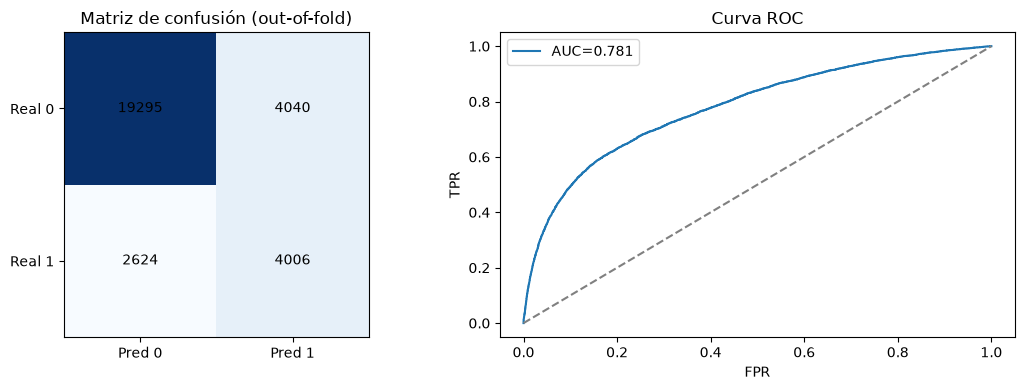

In [9]:
best_row = table.sort_values(f"{metric_for_ranking}_mean", ascending=False).iloc[0]
best_model = best_row["model"]
best_technique = best_row["technique"]
best_method = best_row["method"]
best_params_per_fold = json.loads(best_row["best_params_per_fold"])
print(f"Mejor combinación según {metric_for_ranking}: {best_model} | {best_technique} | {best_method}")

y_true_best, y_pred_best, y_proba_best = regenerate_outof_fold_predictions(
    MODEL_REGISTRY[best_model],
    best_technique,
    best_params_per_fold,
    X,
    y,
    n_outer_folds=int(best_row["n_outer_folds"]),
    random_state=int(best_row["random_state"]),
)

cm = confusion_matrix(y_true_best, y_pred_best, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_true_best, y_proba_best)
auc = roc_auc_score(y_true_best, y_proba_best)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, str(v), ha="center", va="center")
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Pred 0", "Pred 1"]); axes[0].set_yticklabels(["Real 0", "Real 1"])
axes[0].set_title("Matriz de confusión (out-of-fold)")

axes[1].plot(fpr, tpr, label=f"AUC={auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("Curva ROC")
axes[1].legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / f"confusion_roc_{best_model}.png", dpi=150, bbox_inches="tight")
plt.show()

## Calibración: Brier, ECE, reliability diagram (+ recalibración si corresponde)

Para operar el modelo ajustando umbrales de decisión (*decision thresholds*) que optimicen el F1 Score en producción, las probabilidades retornadas deben ser confiables:
- **Diagnóstico:** Se evalúa si el modelo presenta un error de calibración inicial ($ECE > 0.05$). Con `class_weight` o SMOTE un ECE alto es esperable aunque el modelo ordene bien, porque el balanceo desplaza la prevalencia efectiva (la *prior*) y las probabilidades sobrestiman la clase positiva.
- **Recalibración:** Se aplica **Recalibración Isotónica** o Platt según corresponda, corrigiendo la curva de confiabilidad (*Reliability Diagram*). En la corrida el ECE bajó de 0.189 a 0.015, pero medido en un solo fold (el de F1 mediano), por lo que no garantiza calibración en general. Un umbral ajustado sobre probabilidades calibradas podría mejorar el F1, pero no se optimiza aquí.

Brier: 0.1745  ECE: 0.1958  (calibración deficiente: True)


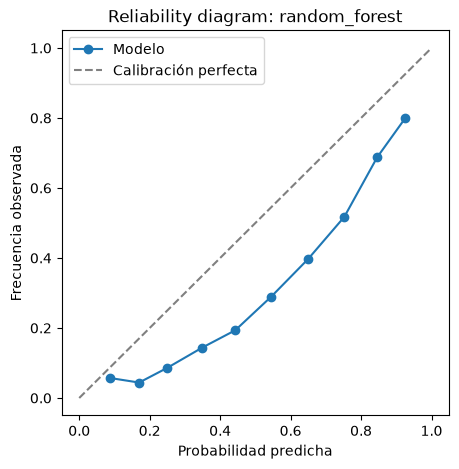

Recalibración (isotonic, fold 0): ECE 0.1904 -> 0.0166 (mejora Brier: 0.0382)


In [10]:
calib = evaluate_calibration(y_true_best, y_proba_best, n_bins=10)
print(
    f"Brier: {calib['brier_score']:.4f}  ECE: {calib['ece']:.4f}  "
    f"(calibración deficiente: {is_calibration_poor(calib['ece'])})"
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(calib["reliability_curve"]["prob_pred"], calib["reliability_curve"]["prob_true"], marker="o", label="Modelo")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha"); ax.set_ylabel("Frecuencia observada")
ax.set_title(f"Reliability diagram: {best_model}"); ax.legend()
plt.savefig(config.FIGURES_DIR / f"reliability_{best_model}.png", dpi=150, bbox_inches="tight")
plt.show()

per_fold_metric = json.loads(best_row[f"{metric_for_ranking}_per_fold"])
# Fold con F1 mediano (no el mejor): evita elegir el fold según el resultado que luego se reporta.
best_fold_idx = int(np.argsort(per_fold_metric)[len(per_fold_metric) // 2])

if is_calibration_poor(calib["ece"]):
    recal = assess_and_recalibrate(
        MODEL_REGISTRY[best_model],
        best_technique,
        best_params_per_fold[best_fold_idx],
        X,
        y,
        best_fold_idx,
        method="isotonic",
        n_outer_folds=int(best_row["n_outer_folds"]),
    )
    print(
        f"Recalibración (isotonic, fold {best_fold_idx}): "
        f"ECE {recal['before']['ece']:.4f} -> {recal['after']['ece']:.4f} "
        f"(mejora Brier: {recal['brier_improvement']:.4f})"
    )
else:
    print("Calibración adecuada, no se aplica recalibración.")

## Complejidad computacional: estándar vs. optimizado

Se compara el costo en tiempo de entrenamiento y memoria RAM de un modelo por defecto (estándar) frente al modelo con la técnica de balanceo e hiperparámetros encontrados (optimizado), junto con el cambio alcanzado en F1 Score. Limitaciones:
- El estándar (hiperparámetros por defecto, sin balanceo) difiere del optimizado en dos cosas a la vez, balanceo e hiperparámetros, así que el aumento de F1 no se puede atribuir solo al ajuste de hiperparámetros.
- `performance_change` se calcula en el fold con F1 mediano (antes se usaba el de mayor F1, que favorecía al modelo optimizado por selección sobre el resultado). Sigue siendo un solo fold.
- La memoria se mide con `tracemalloc`, que solo cuenta memoria asignada desde Python y no la del código nativo (por ejemplo, de XGBoost o SVM), así que la subestima.
- Es una sola medición en un solo fold. Los tiempos son de un único ajuste con los hiperparámetros ya elegidos y no incluyen el costo de la búsqueda.

In [11]:
complexity_row = compare_standard_vs_optimized(
    MODEL_REGISTRY[best_model],
    best_technique,
    best_params_per_fold[best_fold_idx],
    X,
    y,
    best_fold_idx,
    n_outer_folds=int(best_row["n_outer_folds"]),
    scoring=metric_for_ranking,
)

print(f"Complejidad teórica ({best_model}):")
print(f"  Train:      {TRAIN_INFERENCE_COMPLEXITY[best_model]['train']}")
print(f"  Inferencia: {TRAIN_INFERENCE_COMPLEXITY[best_model]['inference']}")

import pandas as pd

pd.DataFrame([complexity_row])[
    [
        "standard_fit_time_seconds",
        "optimized_fit_time_seconds",
        "standard_fit_peak_memory_mb",
        "optimized_fit_peak_memory_mb",
        f"standard_{metric_for_ranking}",
        f"optimized_{metric_for_ranking}",
        "performance_change",
    ]
]

Complejidad teórica (random_forest):
  Train:      O(T·n·p·log n) — T árboles independientes, cada uno O(n·p·log n).
  Inferencia: O(T·log n) por consulta (promedio sobre los T árboles).


,standard_fit_time_seconds,optimized_fit_time_seconds,standard_fit_peak_memory_mb,optimized_fit_peak_memory_mb,standard_f1,optimized_f1,performance_change
0,9.381728,23.744151,7.502861,8.005475,0.473531,0.549328,0.075797


## Siguiente Paso

Con la combinación de mayor F1 medio identificada (su ventaja sobre otras cercanas no es estadísticamente distinguible), avanzamos al notebook `06_interpretability.ipynb`: allí se interpreta con SHAP el Random Forest de esa combinación (100 observaciones de un fold) y se compara LIME frente a SHAP en una observación de XGBoost.